In [133]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the CSV file
# Assuming the file is named 'clusters.csv' and has no header row

df = pd.read_csv('newtest/cluster_results_merged_csv_threshold_50_20250324_185919.csv',)

# # Count occurrences of each cluster label to get cluster sizes
# cluster_sizes = df['Cluster_Label'].value_counts()


In [134]:
df

,File_Path,SHA256,SSDeep,Cluster_Label,Threshold
0,/usr/src/app/datacopy/evasive-it/2021/68f22901...,68f22901ca321609823c5211354ef8946432d77be33150...,24576:waDijudN8S5Wkba6ujrjV30TemCIup7On+gezmGc...,6,50
1,/usr/src/app/datacopy/evasive-it/2021/a470823d...,a470823db33706bd6ea4768a5240e82815fac99ce26dbd...,49152:yug6VZ08JY+VLl6TCmAaYi5Sug6VZ08JY+VLl6TC...,0,50
2,/usr/src/app/datacopy/evasive-it/2021/21fc6ae8...,21fc6ae8f7c0619af4c03ce300bb271f3d3ec43cd196bb...,49152:sabk9V8UtKNAw4OiZrq1DfP+rsNADtV6v+L0uSwi...,7,50
3,/usr/src/app/datacopy/evasive-it/2021/4149f025...,4149f025cfce38098d9b8a048c169651a38d312ed6e026...,6144:1mSUslh44d5nngQFZpX3oGwIz+w5sP6Eg0QhI8bUr...,8,50
4,/usr/src/app/datacopy/evasive-it/2021/55a3c455...,55a3c455cfbd70fd91663e251ea65db6452edbb0d730c8...,6144:/yuMwiLdfF2m7mrUsqWBn837FNldObO3k1j0NooWv...,1,50
5,/usr/src/app/datacopy/evasive-it/2021/b9c705ce...,b9c705cedc02d6ef6ea1764f6dfb0724ce66c878f5c033...,6144:/yuMwiLdfF2m7mrUsqWBn837FNldObO3k1jc:quMw...,1,50
6,/usr/src/app/datacopy/evasive-it/2021/2b81bcbc...,2b81bcbc4e1b8e1c6f7ab1eca090887c0710a73e4fd417...,1536:6drAww4Aw4N/V9oK8fRJ8teVZzfT8o47ywJ6:gcww...,9,50
7,/usr/src/app/datacopy/evasive-it/2021/ce46e8fd...,ce46e8fd19e006eb7dd8c14c64050025d8771fc092097f...,49152:p/E8I0zy/E8I0OnbJg/E8I0zy/E8I0OnbJfr7/E8...,10,50
8,/usr/src/app/datacopy/evasive-it/2021/07a8958e...,07a8958e9a5969c1643093bc114def0d985685e7b34eba...,24576:yAbx96h3Qh3FZIEu8CkBq+M3HpILl6TCTKm5DBMY...,0,50
9,/usr/src/app/datacopy/evasive-it/2021/4bb109e5...,4bb109e5215a2bab1339888ba21156e4ec877d59c38e59...,24576:1mB4bjwTfUGhzC7rxS0LmB4bjwTfUGhzC7rxSXUf...,11,50


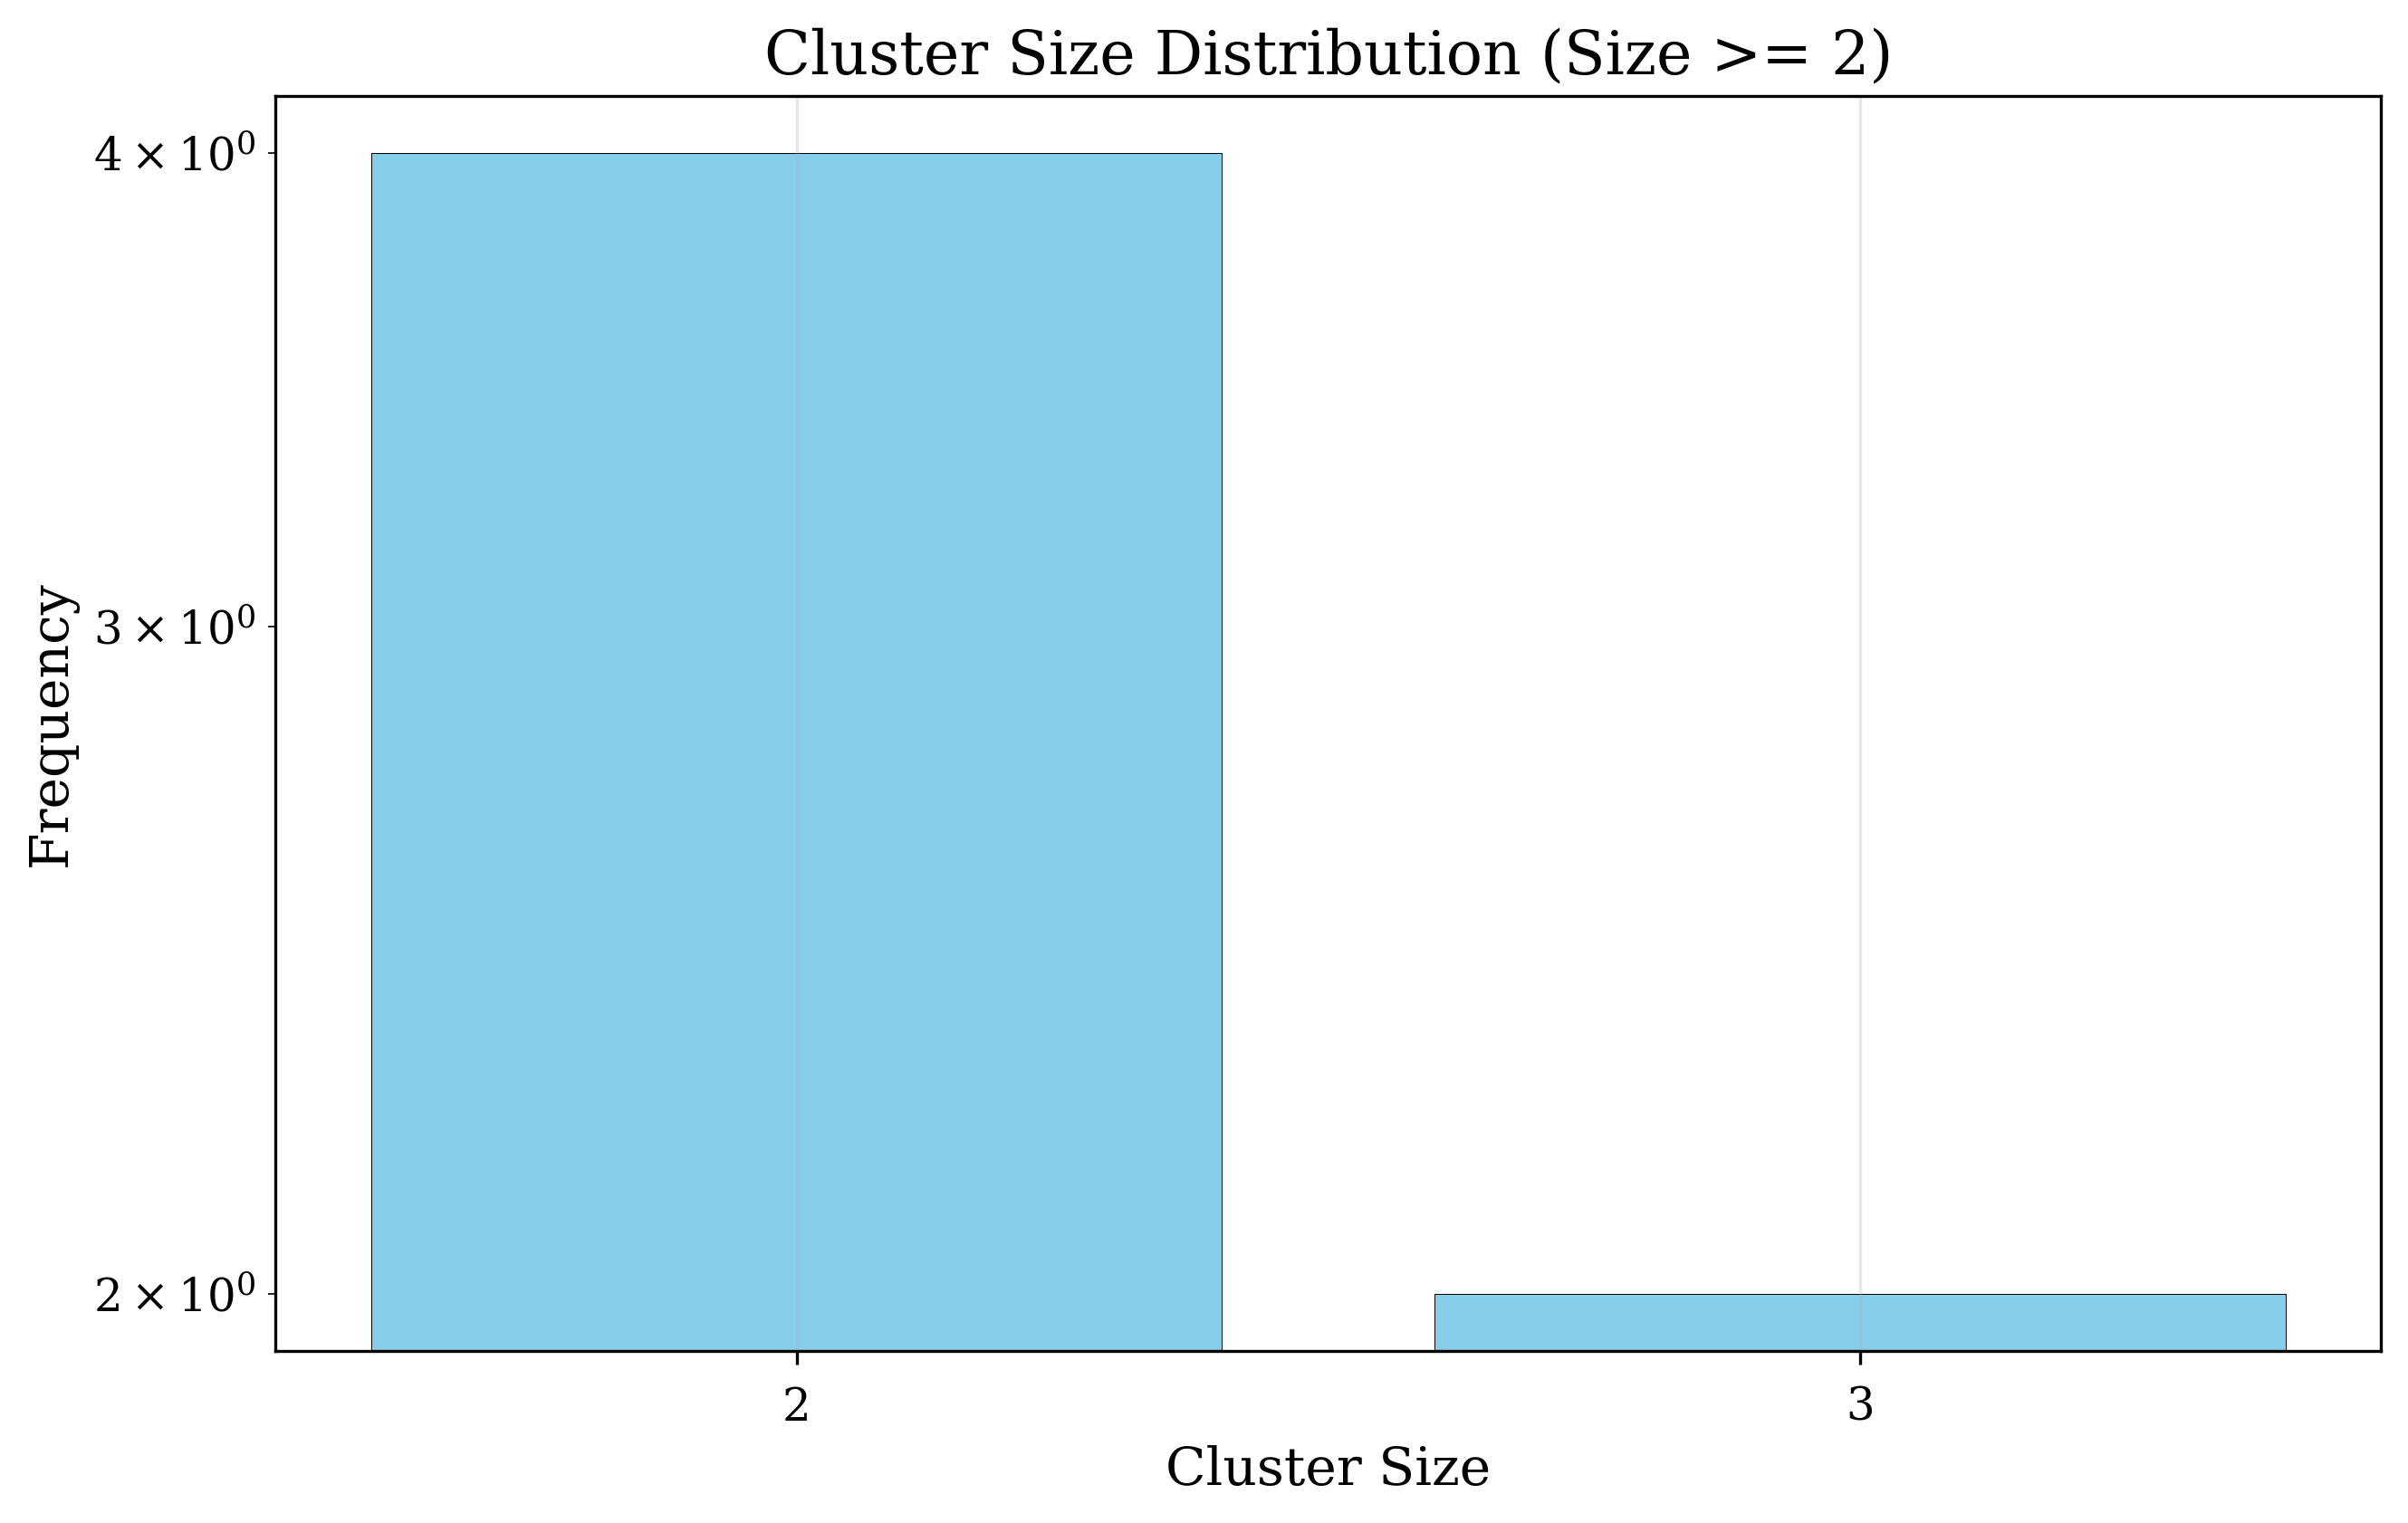

In [135]:

df['Cluster_Label'] = pd.to_numeric(df['Cluster_Label'], errors='coerce')

# Get labels, dropping any NaN
labels = df['Cluster_Label'].dropna().astype(int).tolist()  # Ensure integers

# Calculate cluster sizes (how many times each label appears)
cluster_sizes = {label: labels.count(label) for label in set(labels) if label >= 0}

# Filter for clusters with size >= 2
filtered_sizes = [size for size in cluster_sizes.values() if size >= 2]

# Check if there’s anything to plot
if not filtered_sizes:
    print("No clusters with size >= 2 found.")
else:
    # Plot histogram
    plt.figure(figsize=(10, 6))
    plt.hist(filtered_sizes, bins=range(2, max(filtered_sizes) + 2), 
             align='left', rwidth=0.8, color='skyblue', edgecolor='black')
    plt.yscale('log')  # Log scale as requested earlier
    plt.xticks(range(2, max(filtered_sizes) + 1))  # Ensure integer x-axis
    plt.xlabel("Cluster Size")
    plt.ylabel("Frequency")
    plt.title("Cluster Size Distribution (Size >= 2)")
    plt.grid(True, alpha=0.3)
    plt.show()